# Data Exploration

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Using custom funciton from Michael Albert's class

def summarize_dataframe(df):
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")

In [3]:
full = pd.read_csv('asrs_full.csv')

## Metadata

### General Metadata Summary

In [4]:
full.shape

(33723, 20)

In [5]:
summarize_dataframe(full)

/tmp/ipykernel_901/1810182620.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
anomaly_code,object,0,6664,33723.0,6664,Aircraft Equipment Problem Critical,1974,,,,,,,
location_id,object,0,1903,33723.0,1903,ZZZ.Airport,15229,,,,,,,
aircraft_type,object,35,554,33688.0,554,Commercial Fixed Wing,4791,,,,,,,
reporter_function,object,284,563,33439.0,563,Captain; Pilot Flying,4760,,,,,,,
flight_phase,object,903,347,32820.0,347,Cruise,5064,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0


In [6]:
## Note:

# aircraft type, reporter function, and flight phase can all be imputed to say "missing"
# curious what is happening with synopsis
# days to recurrence should not be imputed, that will be left alone as analysisc can handle the Nan
# word_count has  ameand of 261 and a STD of 216... meaning one third are less than 45

### 'Synopsis' Column

In [7]:
# Looking at the synopses that are alike - trying to find out why there may be duplicates

# Create a list of unique values
unique_synopses = full.synopsis.unique()

# Create a function that returns values that are not unique (i.e. duplicated)
def not_unique(col):
    new_list = []
    for synopsis in col:
        if synopsis not in unique_synopses:
            new_list.append(synopsis)
            
    unique_list = np.unique(new_list)

    return unique_list

not_unique(full.synopsis)

array([nan])

In [8]:
# A second method for checking for duplicates

dupe_rows = full[full.synopsis.duplicated(keep=False)]


In [9]:
# Looks like the synopsis discrepancy is nothing to worry about 

### Simple Imputations

In [10]:
# Fill missing values in the three columns with 'missing'

full['aircraft_type'] = full['aircraft_type'].fillna('missing')
full['reporter_function'] = full['reporter_function'].fillna('missing')
full['flight_phase'] = full['flight_phase'].fillna('missing')

In [11]:
summarize_dataframe(full)

/tmp/ipykernel_901/1810182620.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
anomaly_code,object,0,6664,33723.0,6664,Aircraft Equipment Problem Critical,1974,,,,,,,
location_id,object,0,1903,33723.0,1903,ZZZ.Airport,15229,,,,,,,
aircraft_type,object,0,555,33723.0,555,Commercial Fixed Wing,4791,,,,,,,
reporter_function,object,0,564,33723.0,564,Captain; Pilot Flying,4760,,,,,,,
flight_phase,object,0,348,33723.0,348,Cruise,5064,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0


## Distributions

### Anomaly Code

/tmp/ipykernel_901/773876693.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


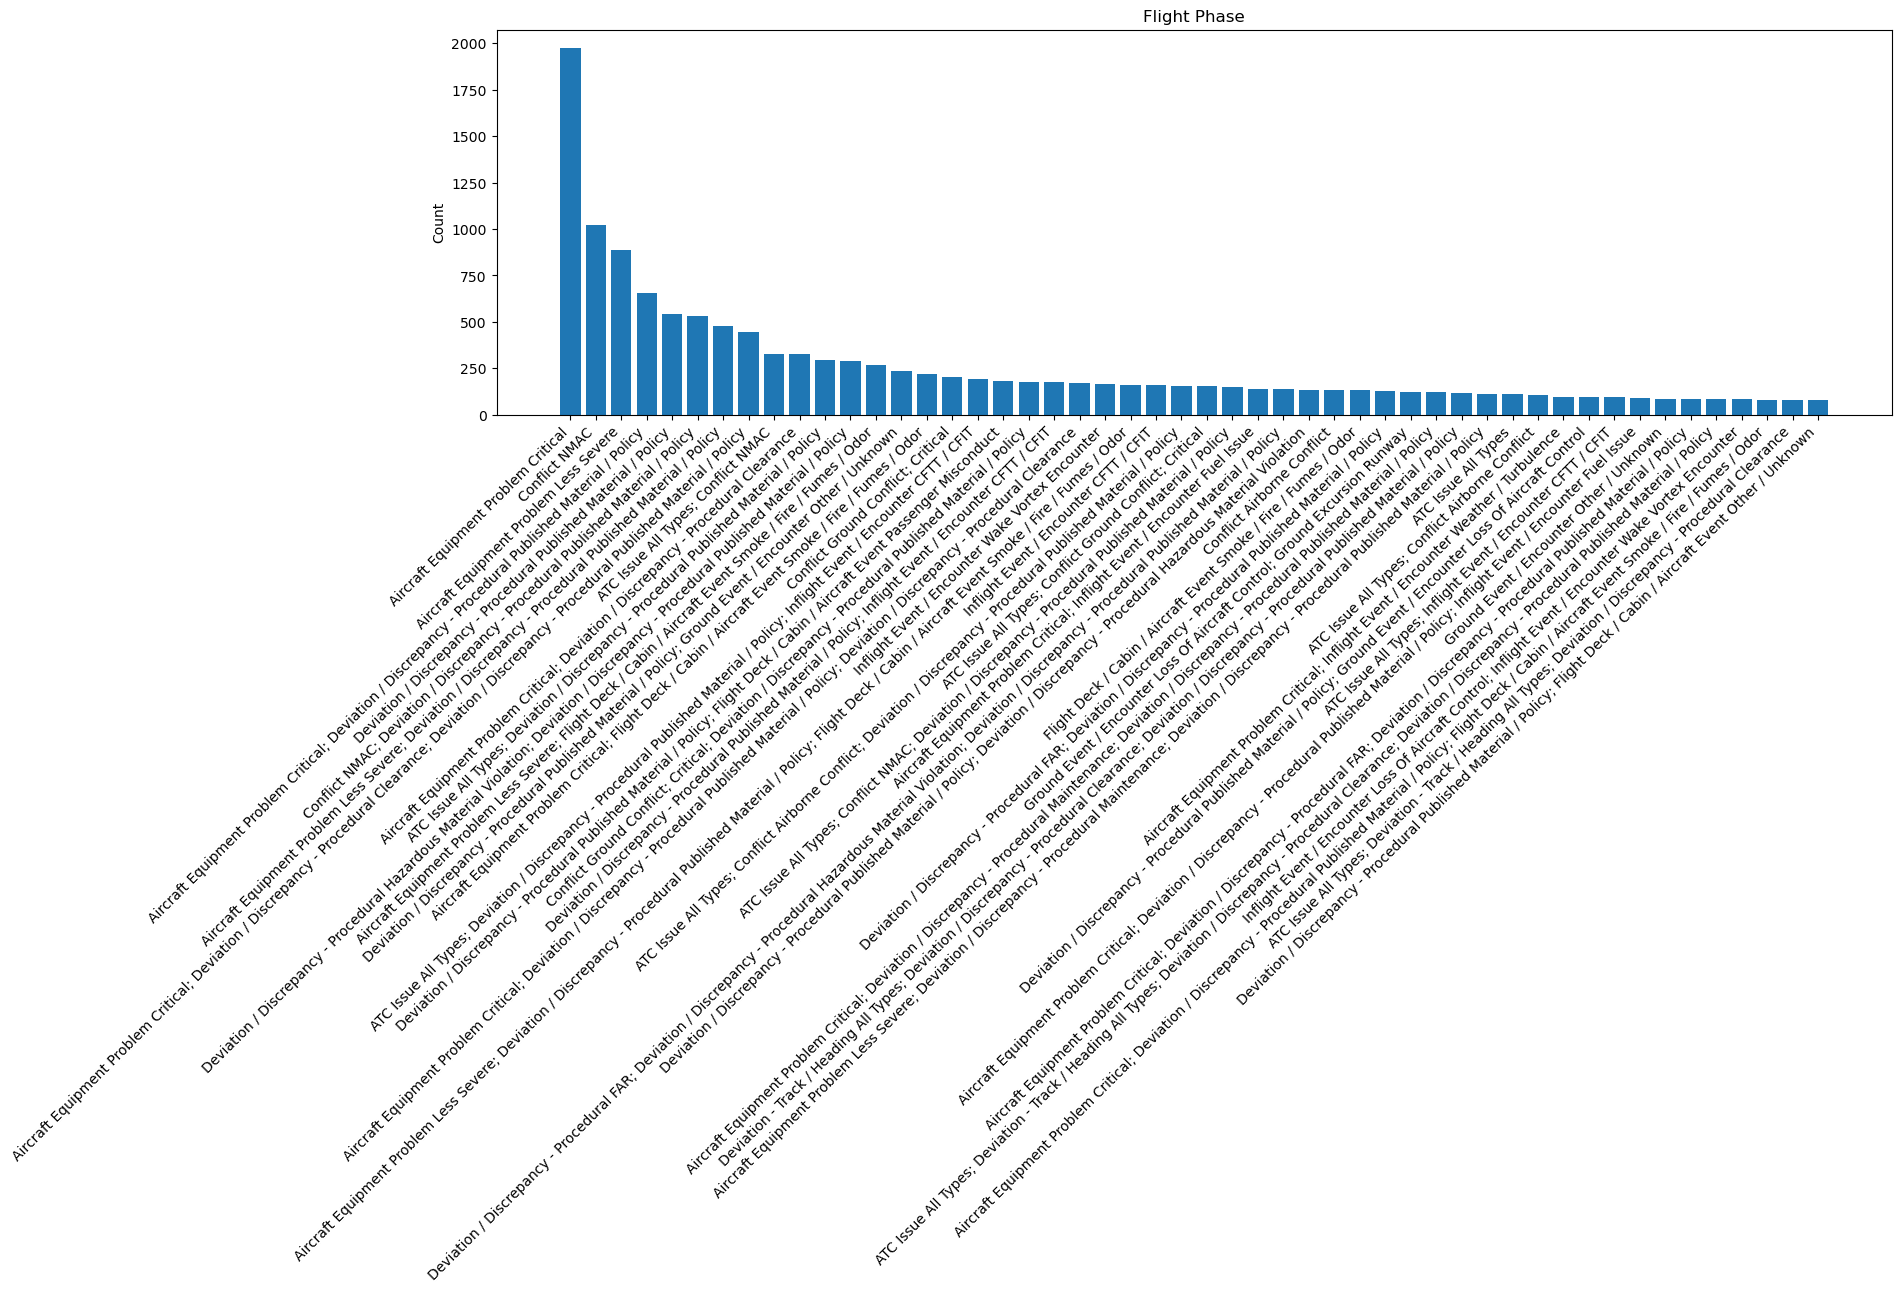

In [12]:
An_counts = full.anomaly_code.value_counts().head(50)

x = An_counts.index
y = An_counts.values

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x, y)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Flight Phase')
ax.set_ylabel('Count')
plt.show()

### Location ID

/tmp/ipykernel_901/4262514697.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


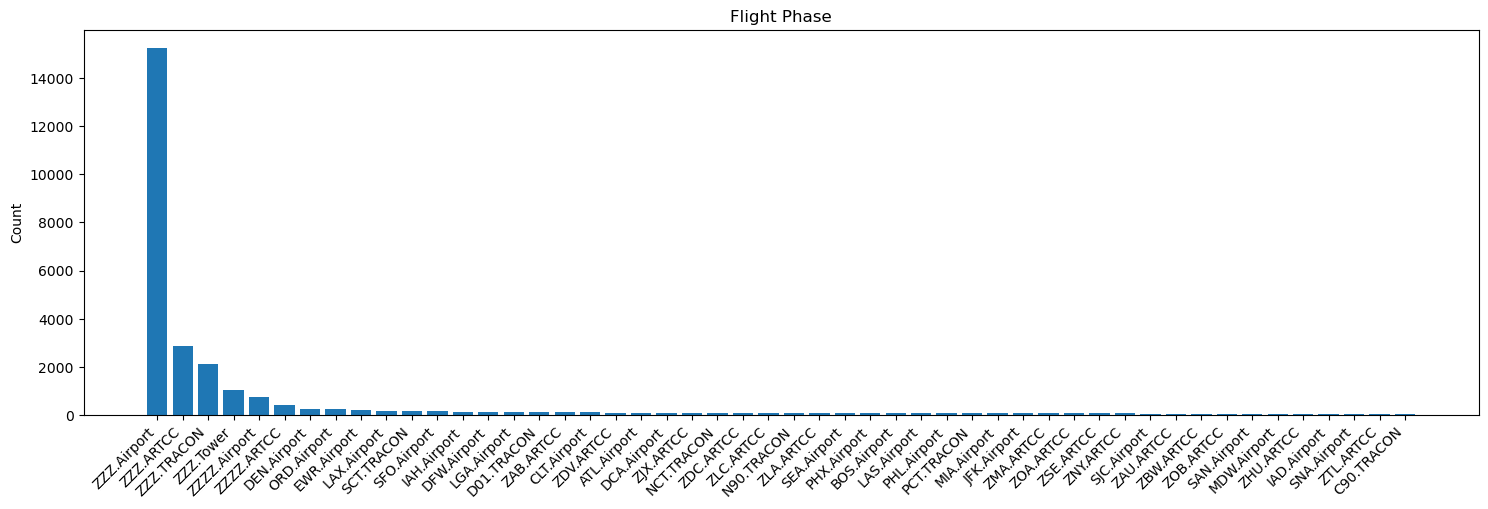

In [13]:
ID_counts = full.location_id.value_counts().head(50)

x = ID_counts.index
y = ID_counts.values

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x, y)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Flight Phase')
ax.set_ylabel('Count')
plt.show()

In [14]:
# About half the data does not include a label for the airport where the incident occurred

In [15]:
full.location_id.value_counts().head(10)

location_id
ZZZ.Airport     15229
ZZZ.ARTCC        2859
ZZZ.TRACON       2123
ZZZ.Tower        1044
ZZZZ.Airport      757
ZZZZ.ARTCC        435
DEN.Airport       256
ORD.Airport       230
EWR.Airport       217
LAX.Airport       177
Name: count, dtype: int64

### Aircraft Type

/tmp/ipykernel_901/2940673468.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


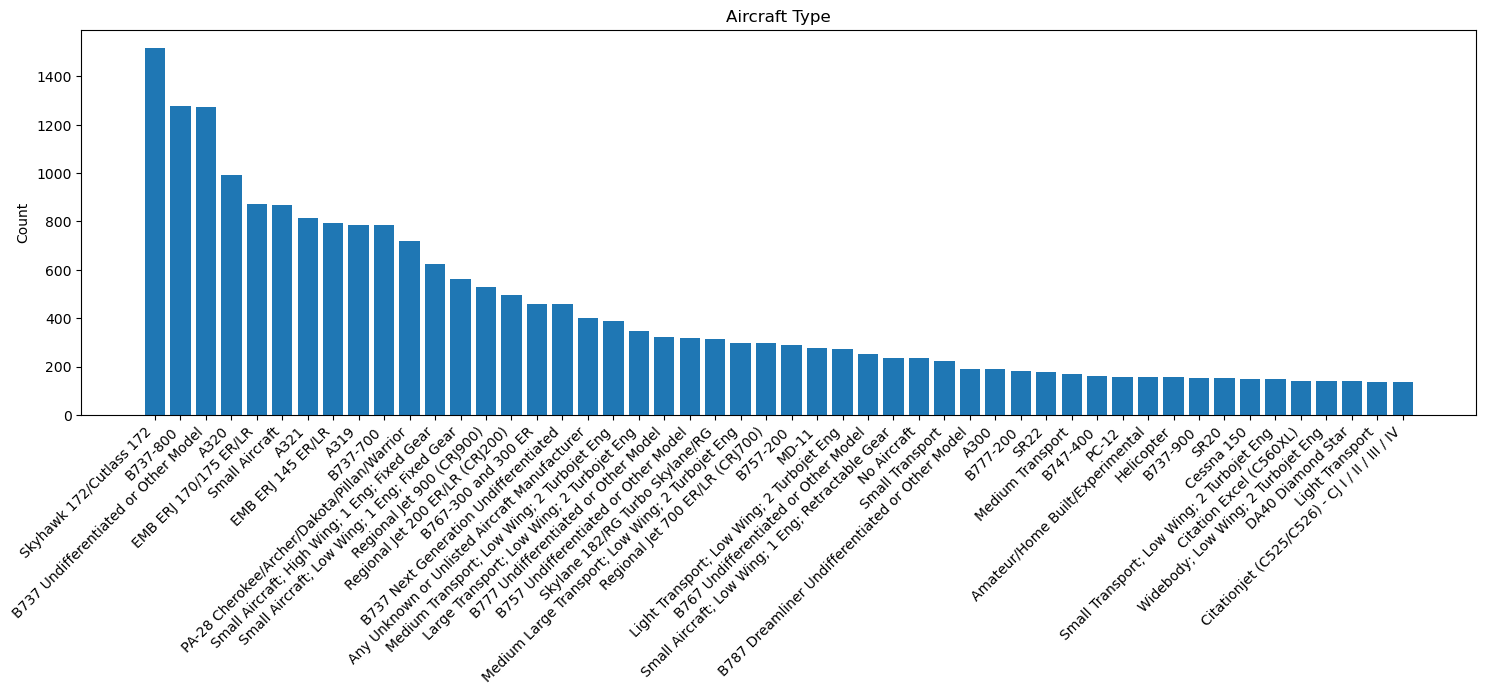

In [16]:
# showing the top 25 and filtering out 'Commercial Fixed Wing, since this accounts for 4791

ac_filtered = full[full['aircraft_type'] != 'Commercial Fixed Wing']

counts = ac_filtered.aircraft_type.value_counts()

x = counts.head(50).index
y = counts.head(50).values

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x, y)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Aircraft Type')
ax.set_ylabel('Count')
plt.show()

In [17]:
len(ac_filtered)

28932

In [18]:
len(counts)

554

In [19]:
lessthree = pd.DataFrame(counts[counts < 50])

In [20]:
lessthree.sum()

count    4606
dtype: int64

### Reporter Function

/tmp/ipykernel_901/359218171.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


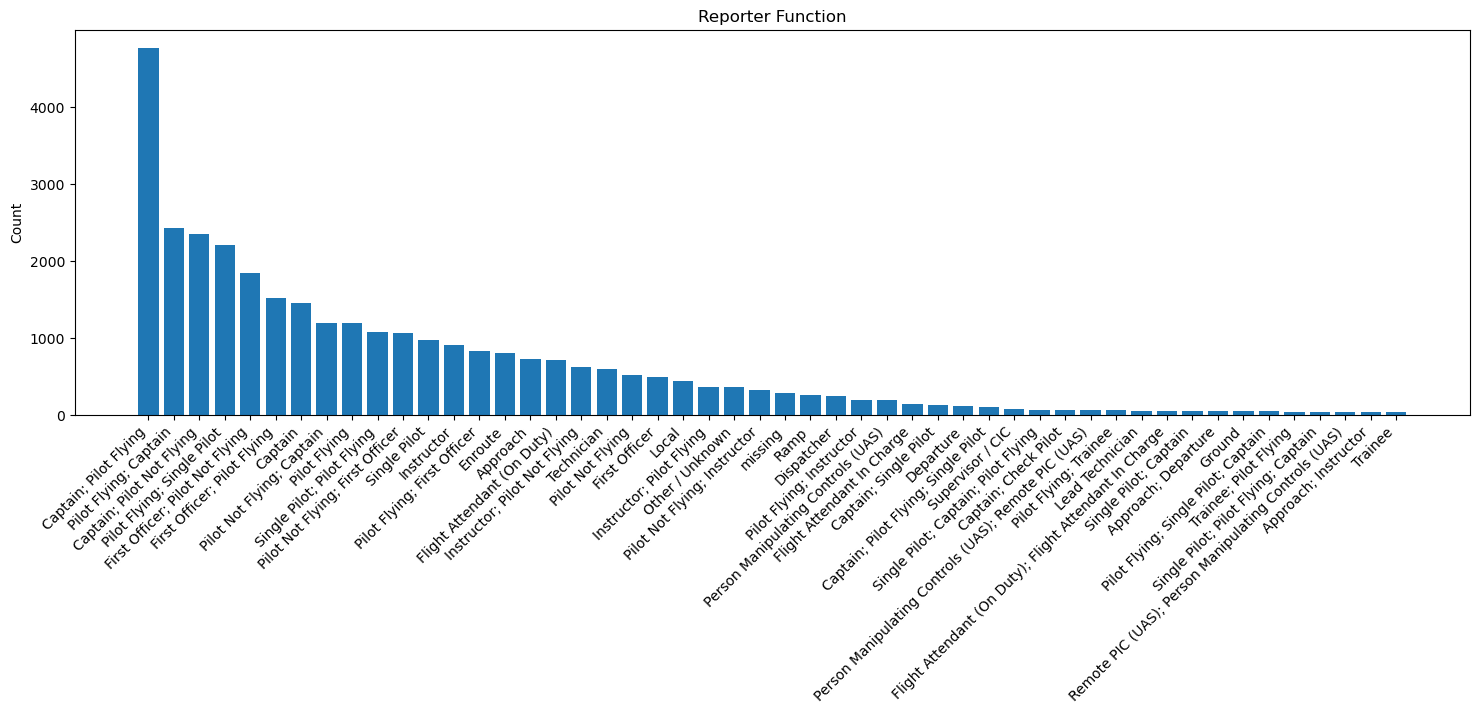

In [21]:

reporter_counts = full.reporter_function.value_counts().head(50)

x = reporter_counts.index
y = reporter_counts.values

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x, y)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Reporter Function')
ax.set_ylabel('Count')
plt.show()

In [22]:
# Note: It looks like there are some redundent labels - like "Pilot Flying: Captain" and "Captain: Pilot Flying" - will need to address this

### Flight Phase

/tmp/ipykernel_901/1062144246.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


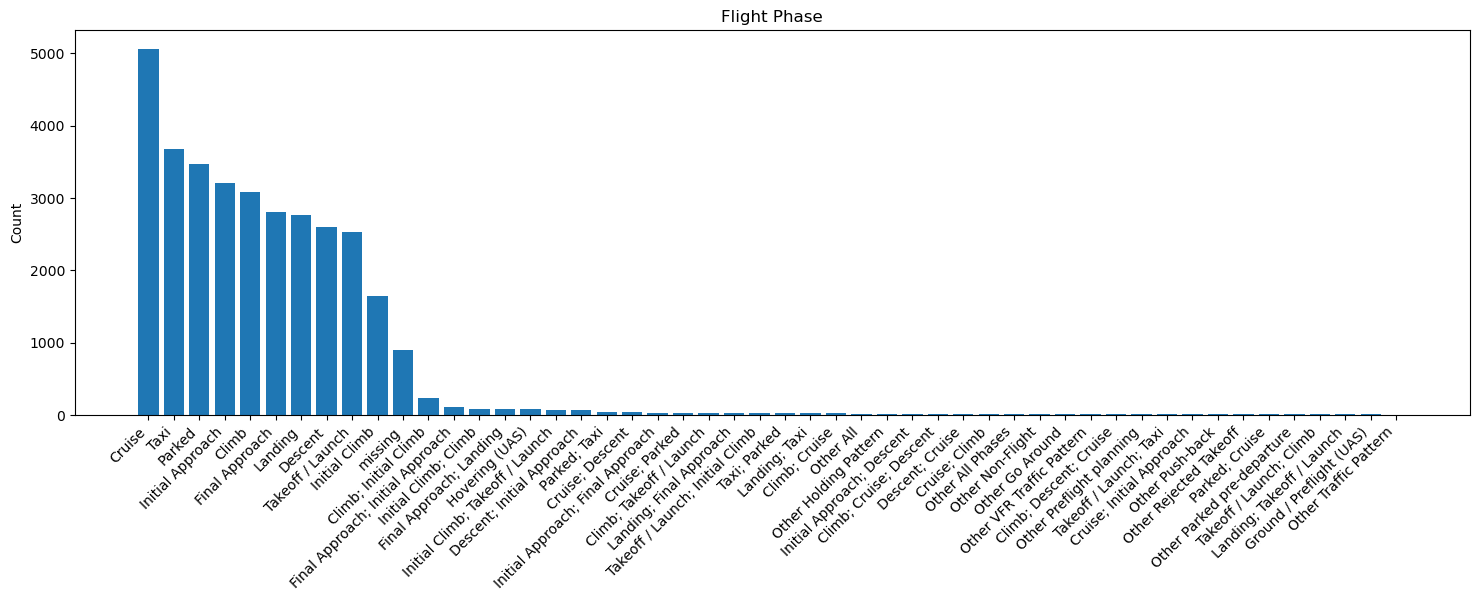

In [23]:
fp_counts = full.flight_phase.value_counts().head(50)

x = fp_counts.index
y = fp_counts.values

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x, y)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Flight Phase')
ax.set_ylabel('Count')
plt.show()

In [24]:
# Note: It looks like there are some redundent labels - like "Climb" and "Initial Climb: Climb" - will need to address this

### Word Count

In [25]:
print(full.word_count.min())
print(full.word_count.max())

2
2345


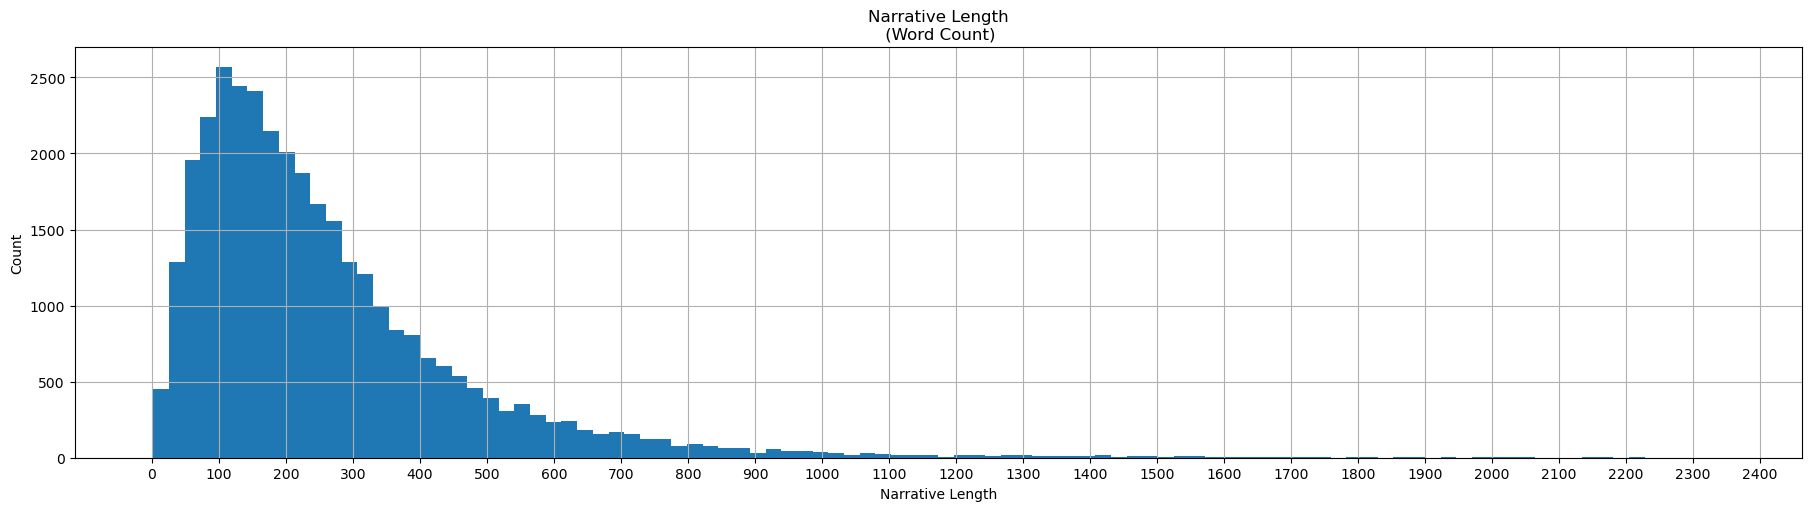

In [26]:
x = full.word_count

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 100, alpha = 1)

ax.set_xlabel('Narrative Length')
ax.set_ylabel('Count')
ax.set_title('Narrative Length\n (Word Count)')
ax.set_xticks(np.arange(0,2500,100))
ax.grid(True)


### Hedge Score

In [27]:
print(full.hedge_score.min())
print(full.hedge_score.max())

0.0
0.142857


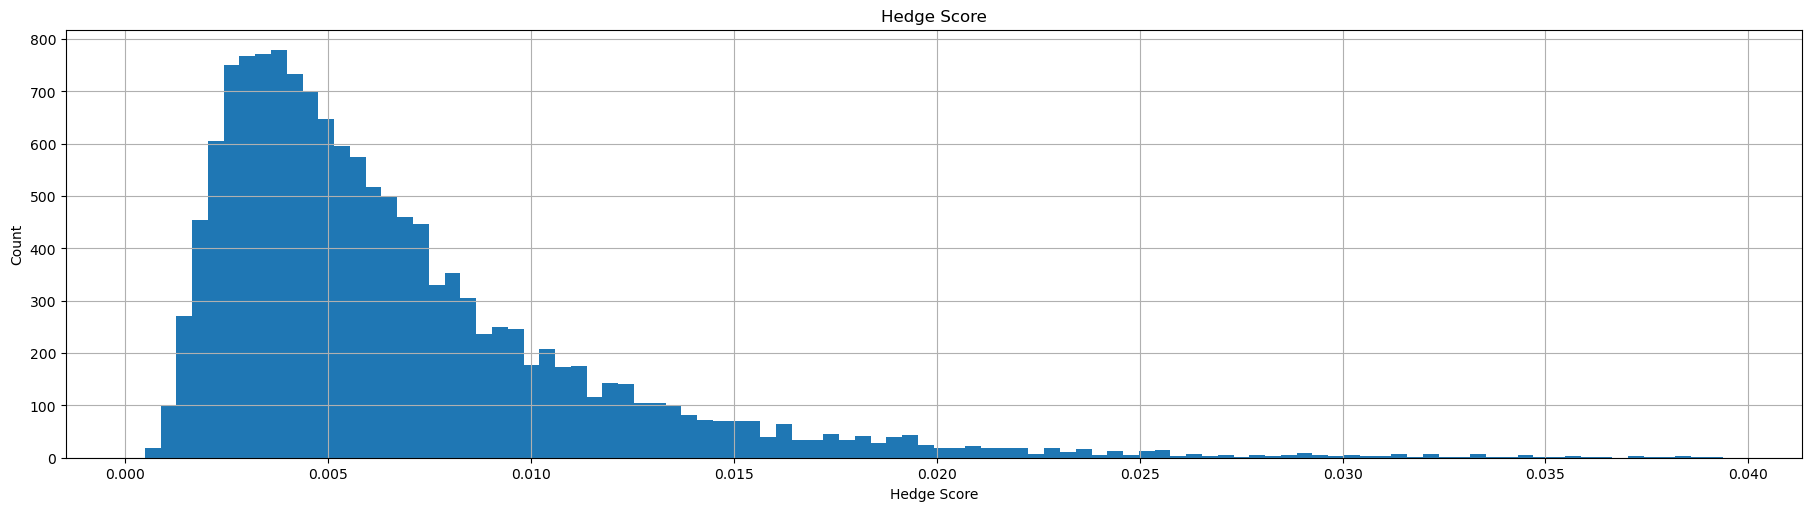

In [28]:
# Filtering the data to show the bulk of the non-zero data - This only represents half the data
x = full[(full['hedge_score'] > 0) & (full['hedge_score'] < 0.04)].hedge_score

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 100, alpha = 1)

ax.set_xlabel('Hedge Score')
ax.set_ylabel('Count')
ax.set_title('Hedge Score')
ax.grid(True)


In [29]:
# Show how many data instances had value 0
full['hedge_score'].value_counts()[0]

np.int64(19718)

### Passive Voice

In [30]:
print(full.passive_voice_ratio.min())
print(full.passive_voice_ratio.max())

0.0
1.0


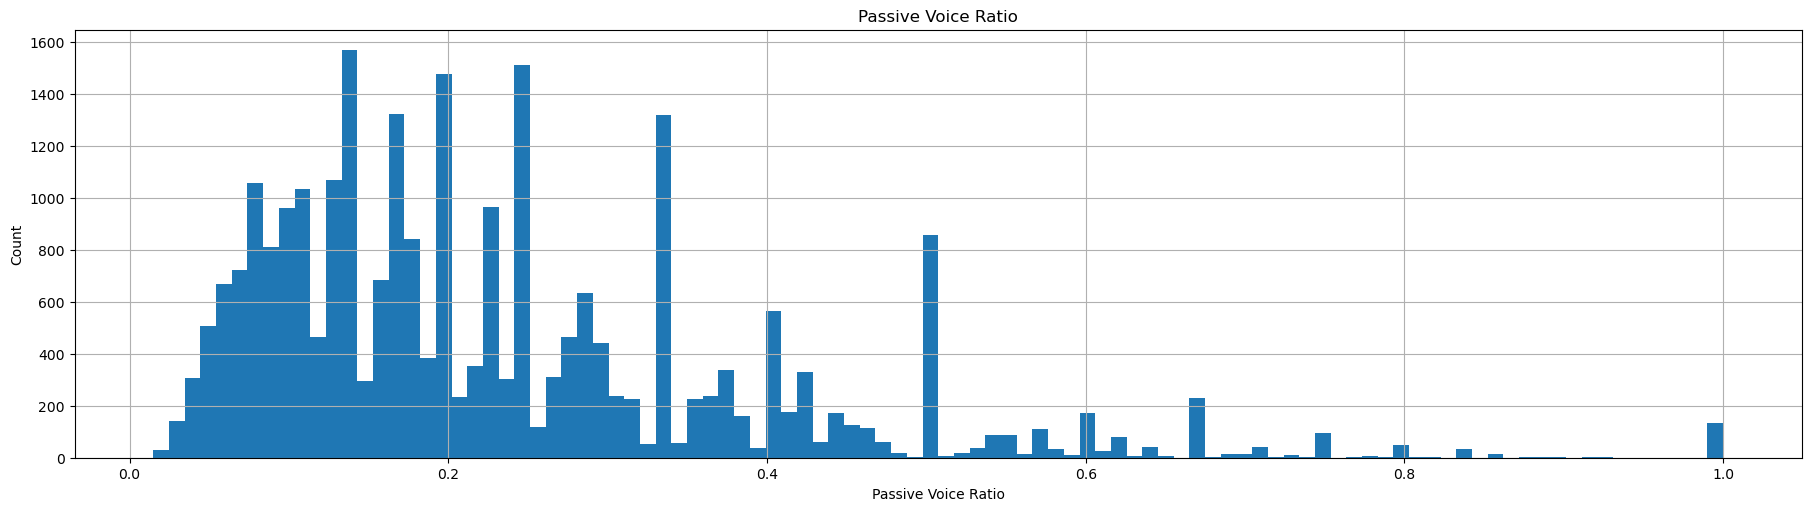

In [31]:
# Filtering the data to show non-zero data
x = full[full['passive_voice_ratio']>0].passive_voice_ratio

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 100, alpha = 1)

ax.set_xlabel('Passive Voice Ratio')
ax.set_ylabel('Count')
ax.set_title('Passive Voice Ratio')
ax.grid(True)


In [32]:
# Show how many data instances had value 0
full['passive_voice_ratio'].value_counts()[0]

np.int64(7269)

### Causal Connective Count

In [33]:
print(full.causal_connective_count.min())
print(full.causal_connective_count.max())

0
20


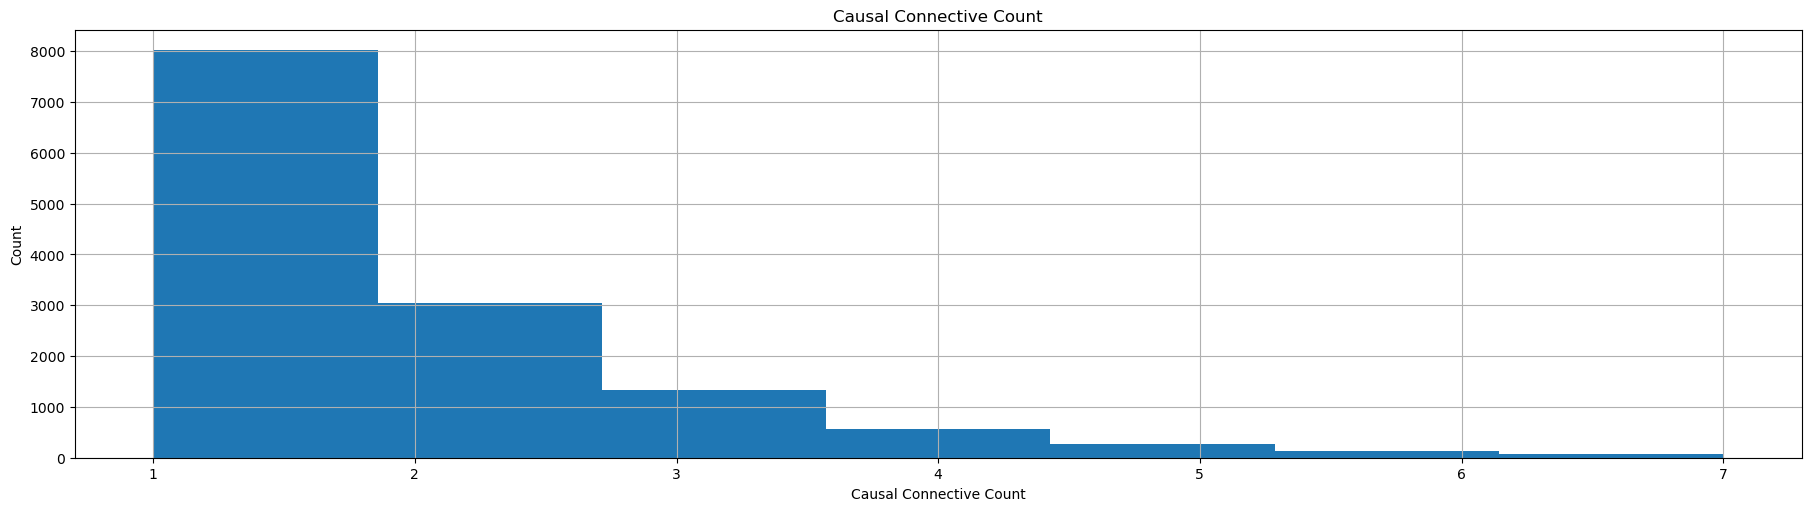

In [34]:
# Filter to show the bulk of non-zero data
x = full[(full['causal_connective_count']>0) & (full['causal_connective_count'] < 8)].causal_connective_count

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 7, alpha = 1)

ax.set_xlabel('Causal Connective Count')
ax.set_ylabel('Count')
ax.set_title('Causal Connective Count')
ax.grid(True)

In [35]:
full['causal_connective_count'].value_counts()[0]

np.int64(20193)

### Specificity Score

In [36]:
print(full.specificity_score.min())
print(full.specificity_score.max())

0.0
1.0


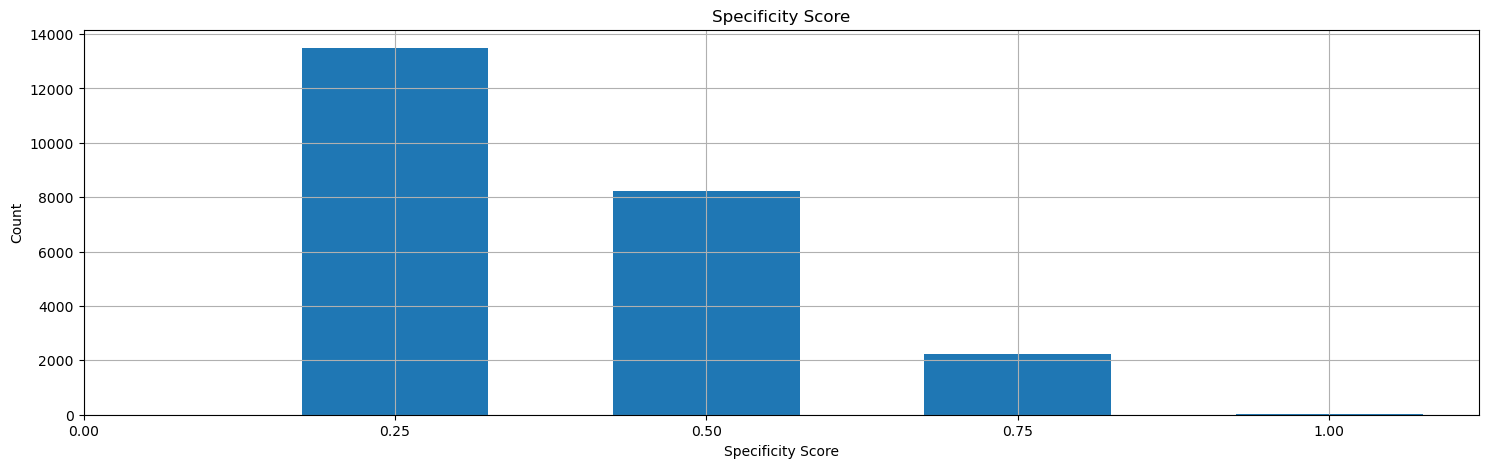

In [37]:

spec_counts = full[full['specificity_score']>0].specificity_score.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(18, 5))

ax.bar(spec_counts.index, spec_counts.values, width=0.15)

ax.set_xlabel('Specificity Score')
ax.set_ylabel('Count')
ax.set_title('Specificity Score')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.grid(True)

In [38]:
# Count of zero data
full['specificity_score'].value_counts()[0]

np.int64(9748)

### Named Entity Count

In [39]:
print(full.named_entity_count.min())
print(full.named_entity_count.max())

0
144


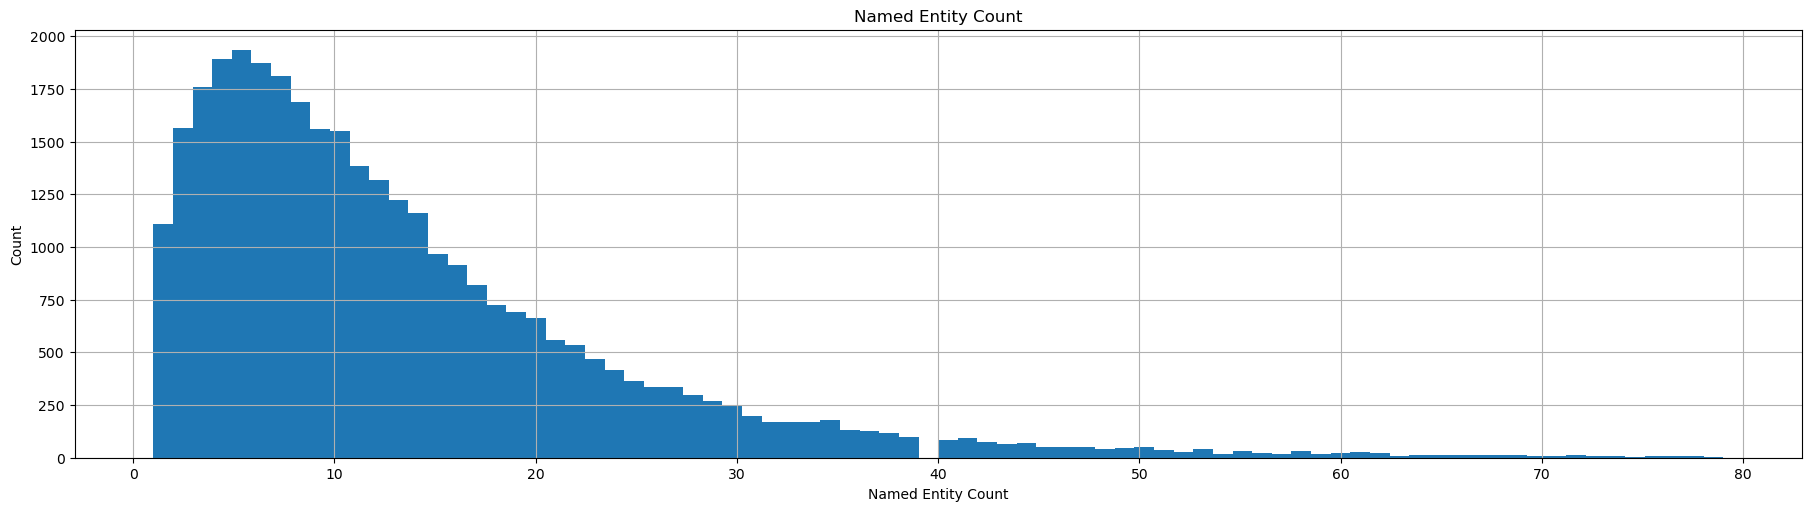

In [40]:
# Filter to show the bulk of non-zero data
x = full[(full['named_entity_count']>0) & (full['named_entity_count']< 80)].named_entity_count

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 80, alpha = 1)

ax.set_xlabel('Named Entity Count')
ax.set_ylabel('Count')
ax.set_title('Named Entity Count')
ax.grid(True)

In [41]:
# Show zeroed data
full['named_entity_count'].value_counts()[0]

np.int64(694)

### Type Token Ratio

In [42]:
print(full.type_token_ratio.min())
print(full.type_token_ratio.max())

0.2023
1.0


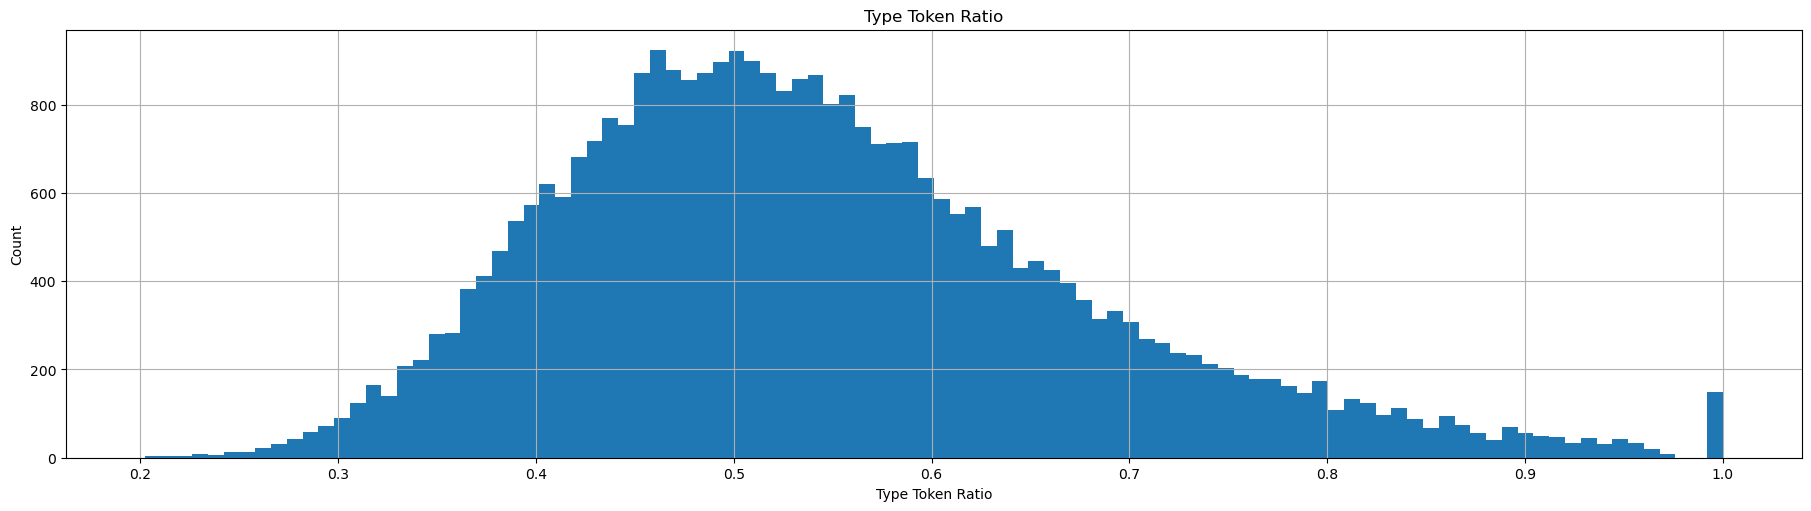

In [43]:
# Filtering the data to show non-zero data
x = full[full['type_token_ratio']>0].type_token_ratio

fig, ax = plt.subplots(figsize=(18, 5), layout = 'constrained')

n, bins, patches, = ax.hist(x, 100, alpha = 1)

ax.set_xlabel('Type Token Ratio')
ax.set_ylabel('Count')
ax.set_title('Type Token Ratio')
ax.grid(True)


In [44]:
# There is no data that is zero

### Severity Scores

In [45]:
# Load the Severity Scores
check = pd.read_csv('/home/jovyan/MSBA Mod 5/Final Deliverable/Data Cleaning and Feature Engineering/Output Files/Data 6 - severity_scores.csv')


In [46]:
print(check['actual_severity'].value_counts())
print(check['potential_severity'].value_counts())

actual_severity
1.0    17695
2.0    13938
3.0     2009
4.0       38
5.0        5
Name: count, dtype: int64
potential_severity
3.0    12857
4.0    12176
2.0     4430
5.0     3758
1.0      465
Name: count, dtype: int64


In [47]:
for i in range(1,6):
    print(f"a{i} = check[check['actual_severity']=={i}].potential_severity")


a1 = check[check['actual_severity']==1].potential_severity
a2 = check[check['actual_severity']==2].potential_severity
a3 = check[check['actual_severity']==3].potential_severity
a4 = check[check['actual_severity']==4].potential_severity
a5 = check[check['actual_severity']==5].potential_severity


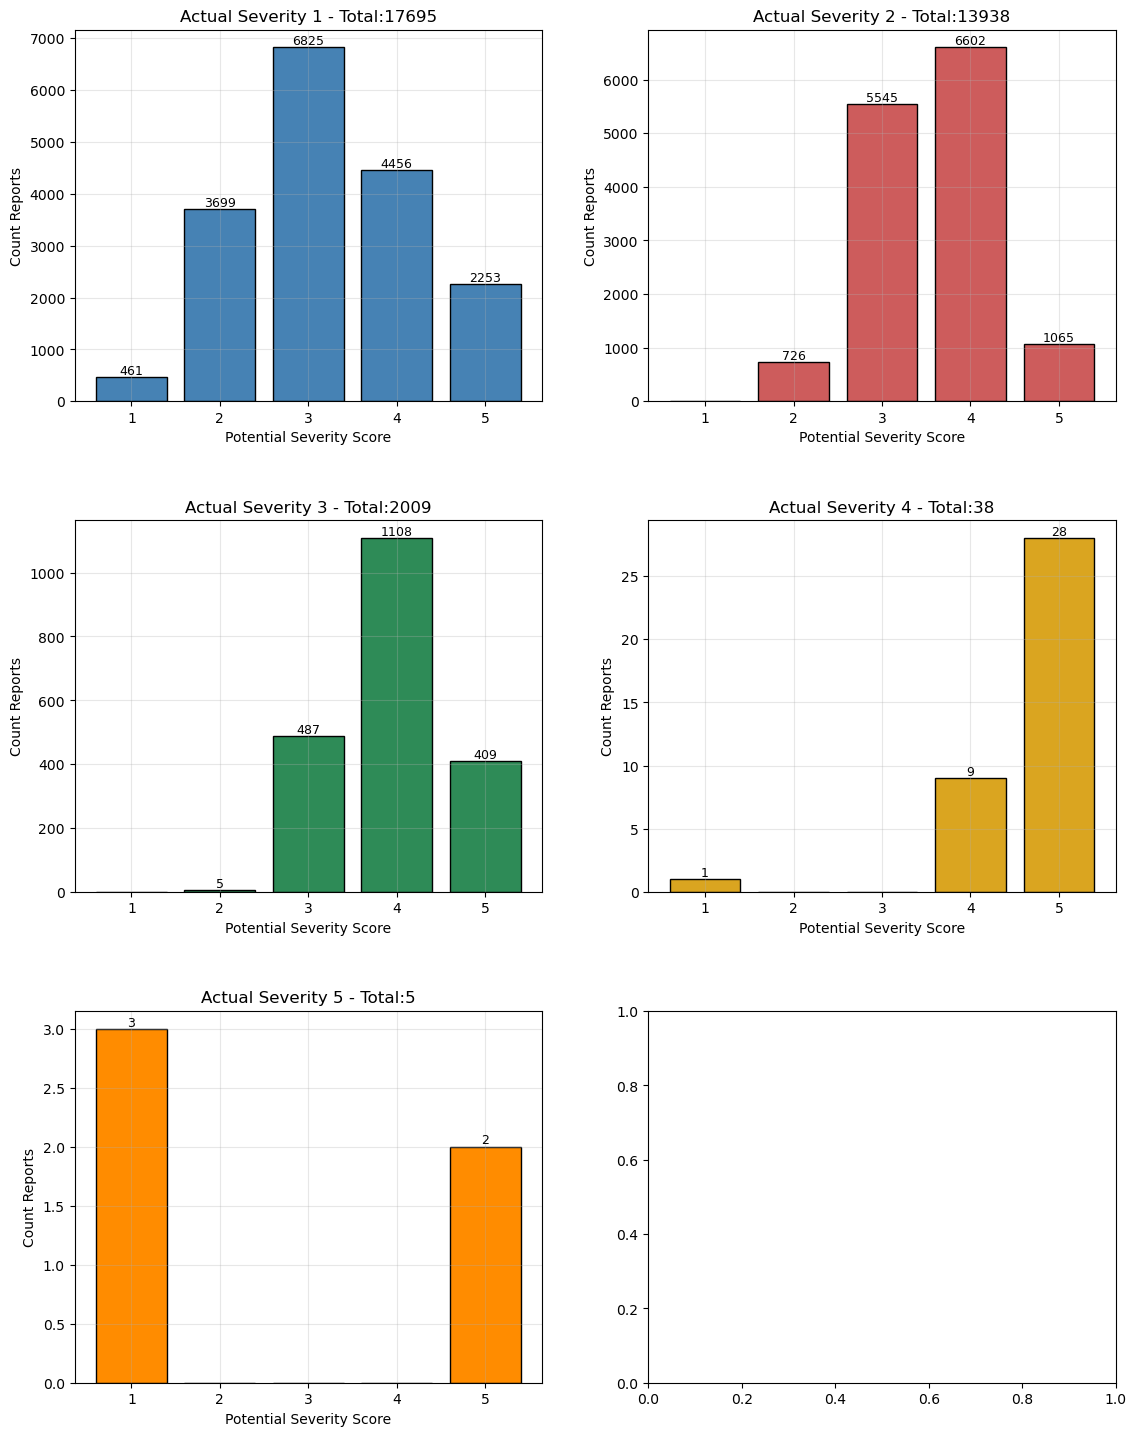

In [48]:
# For each value of actual severity, what is the distribution of potential severities?
a1 = check[check['actual_severity']==1].potential_severity
a2 = check[check['actual_severity']==2].potential_severity
a3 = check[check['actual_severity']==3].potential_severity
a4 = check[check['actual_severity']==4].potential_severity
a5 = check[check['actual_severity']==5].potential_severity

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))

data = [a1, a2, a3, a4, a5]
titles = [f'Actual Severity 1 - Total:{len(a1)}',
          f'Actual Severity 2 - Total:{len(a2)}',
          f'Actual Severity 3 - Total:{len(a3)}',
          f'Actual Severity 4 - Total:{len(a4)}',
          f'Actual Severity 5 - Total:{len(a5)}'
         ]

bin_edges = np.arange(0.5, 6.5, 1)

colors = ['steelblue', 'indianred', 'seagreen', 'goldenrod', 'darkorange']

for ax, x, title, color in zip(axs.flat, data, titles, colors):
    counts, bins, patches = ax.hist(x, bins=bin_edges, density=False, histtype='bar',
                                     rwidth=0.8, color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count Reports')
    ax.set_xlabel('Potential Severity Score')
    ax.set_xticks(np.arange(1, 6, 1))
    ax.grid(True, alpha=0.3)

    # add count labels above each bar
    for count, bin_edge in zip(counts, bins):
        if count > 0:
            ax.text(bin_edge + (bins[1]-bins[0])/2, count, int(count),
                    ha='center', va='bottom', fontsize=9)


fig.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()